# 2.4 CRE–Gene Association via Regression

## How much variance in gene expression can a regression model explain per gene

Regression: wie gut kann ich Genexpression durch ATAC Peaks vorhersagen?

### Theorie

Regressions Modelle

1. assuming a linear relationship <br>
<br>Y = Genexpression  <br>
X = Peak-Accessibility<br>
<br> **Intercept b0:** vorhersage der Expression von Gen, wenn die Accessibilty von Peak = 0 ist<br>
**Slope b1:** Wie stark sich die Expression ändert, wenn die Accessibility steigt<br>

$$\hat{Y}_i = b_0 + b_1 X_i$$

2. Parameters of the regression line are estimated using least-square method <br>
→ minimize the sum of squares of the deviations

$$\min_{b_0, b_1} \sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2$$
$$b_0 = \bar{Y} - b_1 \cdot \bar{X}$$
$$b_1 = corr(X, Y) \frac{s_Y}{s_X}$$


3. Residuen echter wert minus vorhergesagter Wert: $$e_i = Y_i - \hat{Y}_i$$

4. Vergleichen mit einem Nullmodell: Erklärt das Modell mehr als nur der Durschschnitt?

5. SST = SSM + SSR
* **$SST$ (Total Sum of Squares):** Gesamtvarianz in $Y$. Misst, wie stark die Genexpression insgesamt um ihren Mittelwert schwankt.
* **$SSM$ (Model Sum of Squares):** durch das Modell erklärte Varianz. Anteil der Varianz der Genexpression, welche direkt durch die Peak Accessibility erklärt werden kann (Abstand von der Regressionsgerade zum Mittelwert).
* **$SSR$ (Residual Sum of Squares):** nicht erklärte Varianz. Also die Summe der quadrierten Abweichungen zwischen den echten Messwerten und den Vorhersagen des Modells.
<br>
<br>

6. **R²** anteil der Gesamtvarianz welche durch das Modell erkärt wird --> **How much variance in gene expression can a regression model explain per gene?**
$$R^2=\frac{SSM}{SST}$$
* Modell funktionirt gut: Wenn möglichst viel der Varianz in SSM liegt und so wenig wie möglich in **SSR—> SSR < SSM**
​

<h3>Umsetzung Python</h3>

* ein Modell auf alle Zelltypen
* ein Modell spezifisch auf Tγδ

1. Gene wählen
* Tγδ-spezifische Gene (Tilmann: 2.2: hoher Gini) 
* vllt ein paar Houskeeping Gens als kontrolle?
2. ATAC Daten für alle Zelltypen oder auf Tγδ Zellen spezifisch (je nach Modell): Peaks pro Gen auswählen?
3. Matrix und dann Regression mit z.B. Funktion aus scikit 

### Funktion für R^2: all celltypes
(+ plot predict vs actual; + residuenplot)


<h3>Datensatz vorbereiten

In [23]:
import pandas as pd
from pathlib import Path

RNA_seq_path = Path('data') / 'mmc2.csv'
RNA_seq = pd.read_csv(RNA_seq_path)

ATAC_pfiltered_path = Path('data') / 'ATAC_pfiltered.csv'
ATAC_seq = pd.read_csv(ATAC_pfiltered_path)
ATAC_seq

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,2.36,0.10,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
1,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.41,0.10,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
2,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.41,0.10,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50
3,ImmGenATAC1219.peak_6,chr1,3399217,0.06,2.39,1.0,NaN,NaN,2.36,1.64,...,1.34,0.29,0.23,0.89,0.11,0.53,1.40,0.90,2.87,9.09
4,ImmGenATAC1219.peak_7,chr1,3400115,0.44,2.57,1.0,NaN,NaN,0.41,0.10,...,0.87,1.93,0.59,0.11,1.39,2.58,0.75,2.30,2.34,11.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362325,ImmGenATAC1219.peak_512589,chrY,90811728,0.00,2.33,1.0,NaN,Erdr1,0.41,7.41,...,4.98,4.47,2.83,4.93,4.92,5.13,9.13,2.21,6.53,6.11
362326,ImmGenATAC1219.peak_512590,chrY,90812084,0.00,3.12,1.0,NaN,Erdr1,2.36,8.79,...,4.03,4.07,5.87,5.36,3.99,7.12,3.57,2.64,5.59,3.64
362327,ImmGenATAC1219.peak_512591,chrY,90812450,0.00,3.99,1.0,NaN,Erdr1,4.37,8.79,...,3.81,3.34,4.27,6.73,5.53,7.21,5.96,5.17,6.53,6.11
362328,ImmGenATAC1219.peak_512592,chrY,90812906,0.00,3.21,1.0,NaN,Erdr1,0.41,7.41,...,4.28,5.55,4.15,6.88,7.16,6.21,8.75,6.83,8.14,4.64


Signalfilter erstellen, da zu viele Daten. Sodass zumindestens Peak irgendwo offen ist und gewisse Variation zeigt

In [24]:
annotation_cols = ["ImmGenATAC1219.peakID", "chrom", "Summit",
                   "mm10.60way.phastCons_scores", "_-log10_bestPvalue",
                   "Included.in.systematic.analysis", "TSS", "genes.within.100Kb"]

#Alle Peaks und numerische ATAC-Werte
ATAC_numeric_all = ATAC_seq.drop(annotation_cols, axis=1, errors="ignore")

#Mittelwert und Varianz pro Peak
peak_mean_all = ATAC_numeric_all.mean(axis=1)
peak_var_all  = ATAC_numeric_all.var(axis=1)

# Schwellwerte (oberes 50%-Quantil)
mean_thresh_global = peak_mean_all.quantile(0.5)
var_thresh_global  = peak_var_all.quantile(0.5)

#Filter
filter_meanvar = (peak_mean_all >= mean_thresh_global) & (peak_var_all >= var_thresh_global)

#Gefiltertes ATAC-DataFrame speichern
ATAC_seq_filtered = ATAC_seq.loc[filter_meanvar].copy()

print(f"Peaks vor Filter: {ATAC_seq.shape[0]}, nach Filter: {ATAC_seq_filtered.shape[0]}")

Peaks vor Filter: 362330, nach Filter: 148110


<h3> Funktion vom Regressionsmodell (R^2) für beliebige Gene 

Lineares Regressionsmodell war zu unzuverlässig aufgrund zu hoher Kollinearität der Peaks --> Lösung mit Ridge arbeiten
<br>
<br>Lineares Regressionsmodell: Parameters of the regression line are estimated using least-square method → minimize the sum of squares of the residuen <br> denn starke Korrelation --> große Koeffizienten <br>

deswegen **Ridge Modell** verwendet, welches penalty einführt für zu große Koeffizienten --> stabiler: 
<br> $$\min_{w} ||Xw - y||^2_2 + \alpha ||w||^2_2$$
<br> least square: $$||Xw - y||^2_2$$ 
<br>penalty: $$\alpha ||w||^2_2$$ 

Danach immernoch gleiches Problem: Kontrollieren mit **Cross validation**
<br> <br> skitlearn: 3.1. Cross-validation: evaluating estimator performance --> problem: overfitting (Modell passt sich zu perfekt an die Trainingsdaten ran) <br>

Lösung: Cross Validation:<br>
1. Die gesamten Daten werden in $K$ gleich große Teile (Folds/Blöcke) aufgeteilt (z. B. 5 Teile).<br>
2. Das Modell wird nun 5-mal hintereinander trainiert und getestet.<br>
3. In jedem Durchgang (Split) dient ein anderer Block als Testdaten (Validierungsdaten) und die restlichen 4 Blöcke als Trainingsdaten.<br>

Ergebnis: negative R^2 Werte: Modell zeigt IL17f-Expression schlechter als durch Mittelwert 
Grund: kaum Variation in den Daten --> alle Expresisonswerte bei 1 und haben auch nur 13 Zelltypen

Modell auf alle Zelldaten anwenden etwas besser

Matrix erstellen: X = peaks, Y = IL17f-Expression

In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import make_pipeline


annotation_cols = ["ImmGenATAC1219.peakID", "chrom", "Summit",
                   "mm10.60way.phastCons_scores", "_-log10_bestPvalue",
                   "Included.in.systematic.analysis", "TSS", "genes.within.100Kb"]


def r2_gen(gen_name, plot=True, plot_residues=True):    # ohne top_k
    
    #Y: Gen-Expression
    RNA_seq_gen = RNA_seq[RNA_seq["Unnamed: 0"] == gen_name]  #Gen Namen von Unnamed in gen_name speichern
    y = RNA_seq_gen.drop("Unnamed: 0", axis=1, errors="ignore").T   #Unnamed zeile entfernen und Matrix transponiernen (Zelltypen sind Zeilen)

    #ATAC datenstz transformieren: Spalten = Peaks
    ATAC_seq_gen = ATAC_seq_filtered.copy()

    peak_ids = ATAC_seq_gen["ImmGenATAC1219.peakID"].values
    X = ATAC_seq_gen.drop(annotation_cols, axis=1, errors="ignore").T

    #nur gemeinsame Zellen behalten behalten
    cells = X.index.intersection(y.index)
    X = X.loc[cells]
    y = y.loc[cells]

    X_scaled = StandardScaler().fit_transform(X) #Spaltenweise z-transformation

    # Ridge-Regressionamodell von scikit-learn
    # alpha ist penalty, wenn alpha = 0 keine Strafe #.fit: trainiert Modell

    ridge = RidgeCV(alphas=[10, 100, 1000, 10000, 100000],cv=KFold(5, shuffle=True, random_state=0))
    ridge.fit(X_scaled, y)

    #y wird verglichen mit vorhergesagten Wert und berechnet R^2 (wie viel Prozent der Expressionsvarianz das Modell erklärt)
    r2 = ridge.score(X_scaled, y)
    best_alpha = ridge.alpha_

    # Cross-Validation mit bestem alpha
    cv = cross_val_score(
        make_pipeline(StandardScaler(), Ridge(alpha=best_alpha)),
        X, y,
        cv=KFold(5, shuffle=True, random_state=0),
        scoring="r2").mean()
    
    y_true = np.ravel(y.values).flatten() #ravel: Ausgabe 1D --> verwenden für scatter plot
    y_pred = ridge.predict(X_scaled).flatten()

    if plot:
        Reg_vis = pd.DataFrame({"y_actual": y_true, "y_pred": y_pred}) #DataFrame mit y und yhut
        sns.scatterplot(data=Reg_vis, x="y_actual", y="y_pred", s=100)
        sns.regplot(data=Reg_vis, x="y_actual", y="y_pred", scatter=False,
                    line_kws={"color": "red"})
        plt.title(f"Actual vs Predicted R^2 for {gen_name}-Expression across all cells")
        plt.show()

    if plot_residues:
        residuals = y_true - y_pred
        Reg_vis = pd.DataFrame({"residuals": residuals, "y_pred": y_pred}) #DataFrame mit yhut und residuals
        sns.scatterplot(data=Reg_vis, x="y_pred", y="residuals", s=100)
        plt.axhline(0, color="red", linestyle="--")
        sns.regplot(data=Reg_vis, x="y_pred", y="residuals", ci=None,
                    scatter=False, line_kws={"color": "blue", "linestyle": "--"})
        plt.title(f"Residual plot {gen_name}-Expression across all cells")
        plt.show()

    return r2, cv, X.shape[1], ridge, best_alpha, peak_ids

<h3> R²_gen for Genes mit hohem Gini-Koeffizient bei all cells</h3> 
<br> Predicted Values und Residuenplot dargestellt

In [26]:
for gen_name in ["Il17f", "Rorc", "Sox13", "Gzma", "Eomes", "Actb"]: 
    r2, cv, n,_, best_alpha,_ = r2_gen(gen_name, plot=False, plot_residues=False) #variabeln brauche ich hier für nicht
    print(f"{gen_name}: R²={r2:.3f}, CV={cv:.3f}, peaks={n}, best_alpha={best_alpha}") #Anzahl der peaks über Zellen hinweg

Il17f: R²=0.745, CV=-49.388, peaks=148110, best_alpha=100000
Rorc: R²=1.000, CV=0.694, peaks=148110, best_alpha=10
Sox13: R²=0.801, CV=-155.537, peaks=148110, best_alpha=100000
Gzma: R²=1.000, CV=0.875, peaks=148110, best_alpha=10
Eomes: R²=1.000, CV=0.956, peaks=148110, best_alpha=10
Actb: R²=0.833, CV=0.302, peaks=148110, best_alpha=100000


sehr großes alpha und teils noch negative CV Werte. Das Modell darf nicht quantiativ interpretiert werden. Im weiteren Verlauf eher dazu verwendet Regresssions Coeffizienten relativ zu vergleichen. 

### Funktion für R^2: Tγδ specific cells
(+ plot predict vs actual; + residuenplot)

<h3> Datensatz vorbereiten

In [8]:
import pandas as pd
from pathlib import Path

RNA_seq_gd_path = Path('data') / 'RNA_seq_gd_anot.csv'
RNA_seq_gd = pd.read_csv(RNA_seq_gd_path)

ATAC_gd_path = Path('data') / 'ATAC_seq_gd.csv'
ATAC_seq_gd = pd.read_csv(ATAC_gd_path)

**Signalfilter** erstellen, da zu viele Daten. Sodass zumindestens Peak irgendwo offen ist und gewisse Variation zeigt

In [39]:
annotation_cols = ["ImmGenATAC1219.peakID", "chrom", "Summit",
                   "mm10.60way.phastCons_scores", "_-log10_bestPvalue",
                   "Included.in.systematic.analysis", "TSS", "genes.within.100Kb"]

#Alle Peaks und numerische ATAC-Werte
ATAC_numeric_gd = ATAC_seq_gd.drop(annotation_cols, axis=1, errors="ignore")

#Mittelwert und Varianz pro Peak
peak_mean_gd = ATAC_numeric_gd.mean(axis=1)
peak_var_gd  = ATAC_numeric_gd.var(axis=1)

# Schwellwerte (oberes 50%-Quantil)
mean_thresh_global = peak_mean_gd.quantile(0.5)
var_thresh_global  = peak_var_gd.quantile(0.5)

#Filter
filter_meanvar_gd = (peak_mean_gd >= mean_thresh_global) & (peak_var_gd >= var_thresh_global)

#Gefiltertes ATAC-DataFrame speichern
ATAC_seq_gd_filtered = ATAC_seq_gd.loc[filter_meanvar_gd].copy()

print(f"Peaks vor Filter: {ATAC_seq_gd.shape[0]}, nach Filter: {ATAC_seq_gd_filtered.shape[0]}")

Peaks vor Filter: 362330, nach Filter: 162133


<h3> Funktion vom Regressionsmodell (R^2): Tγδ cells 

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns  
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import make_pipeline 


annotation_cols = ["ImmGenATAC1219.peakID", "chrom", "Summit",
                   "mm10.60way.phastCons_scores", "_-log10_bestPvalue",
                   "Included.in.systematic.analysis", "TSS", "genes.within.100Kb"]


def r2_gen_gd(gen_name_gd, plot=True, plot_residues=True):   # top_k weg
    # RNA
    RNA_seq_Tgd_gen = RNA_seq_gd[RNA_seq_gd["Unnamed: 0"] == gen_name_gd]
    y = RNA_seq_Tgd_gen.drop("Unnamed: 0", axis=1, errors="ignore").T

    # ATAC
    ATAC_seq_gd_gen = ATAC_seq_gd_filtered.copy()
    
    peak_ids = ATAC_seq_gd_gen["ImmGenATAC1219.peakID"].values  # ← vor .T
    X = ATAC_seq_gd_gen.drop(annotation_cols, axis=1, errors="ignore").T

    # gemeinsame Zellen angleichen
    cells = X.index.intersection(y.index)
    X = X.loc[cells]
    y = y.loc[cells]
    
    X_scaled = StandardScaler().fit_transform(X)

    ridge = RidgeCV(alphas=[10, 100, 1000, 10000, 100000], cv=KFold(5, shuffle=True, random_state=0))
    ridge.fit(X_scaled, y)

    r2 = ridge.score(X_scaled, y)
    best_alpha = ridge.alpha_
    
    # CV mit bestem alpha
    cv = cross_val_score(
        make_pipeline(StandardScaler(), Ridge(alpha=best_alpha)),
        X, y,
        cv=KFold(5, shuffle=True, random_state=0),
        scoring="r2"
    ).mean()

    y_actual = np.ravel(y.values).flatten()
    y_pred = ridge.predict(X_scaled).flatten()

    if plot:
        Reg_vis = pd.DataFrame({"y_actual": y_actual, "y_pred": y_pred})
        sns.scatterplot(data=Reg_vis, x="y_actual", y="y_pred", s=100)
        sns.regplot(data=Reg_vis, x="y_actual", y="y_pred", scatter=False,
                    line_kws={"color": "red"})
        plt.title(f"Actual vs Predicted R^2 for {gen_name_gd}-Expression across Tgd cells")
        plt.show()

    if plot_residues:
        residuals = y_actual - y_pred
        Reg_vis = pd.DataFrame({"residuals": residuals, "y_pred": y_pred})
        sns.scatterplot(data=Reg_vis, x="y_pred", y="residuals", s=100)
        plt.axhline(0, color="red", linestyle="--")
        sns.regplot(data=Reg_vis, x="y_pred", y="residuals", ci=None,
                    scatter=False, line_kws={"color": "blue", "linestyle": "--"})
        plt.title(f"Residual plot {gen_name_gd}-Expression across Tgd cells")
        plt.show()
    
    return r2, cv, X.shape[1], ridge, best_alpha, peak_ids

<h3> R²_gen_gd for Genes mit hohem Gini-Koeffizient bei Tgd-Zellen</h3> 
<br> Predicted Values und Residuenplot dargestellt

In [41]:
for gen_name_gd in ["Il17f", "Rorc", "Sox13", "Gzma", "Eomes", "Actb"]: 
    r2, cv, n,_,best_alpha, _ = r2_gen_gd(gen_name_gd, plot=False, plot_residues=False)
    print(f"{gen_name_gd}: R²={r2:.3f}, CV={cv:.3f}, peaks={n}, best_alpha={best_alpha}") #Anzahl der peaks über Zellen hinweg

Il17f: 162133 Peaks im Tγδ-Modell nach Filter
Il17f: R²=1.000, CV=-26.871, peaks=162133, best_alpha=10
Rorc: 162133 Peaks im Tγδ-Modell nach Filter
Rorc: R²=1.000, CV=-4636.228, peaks=162133, best_alpha=10
Sox13: 162133 Peaks im Tγδ-Modell nach Filter
Sox13: R²=1.000, CV=-26.505, peaks=162133, best_alpha=10
Gzma: 162133 Peaks im Tγδ-Modell nach Filter
Gzma: R²=1.000, CV=-3.556, peaks=162133, best_alpha=10
Eomes: 162133 Peaks im Tγδ-Modell nach Filter
Eomes: R²=0.999, CV=-11266.920, peaks=162133, best_alpha=10000
Actb: 162133 Peaks im Tγδ-Modell nach Filter
Actb: R²=0.883, CV=-0.145, peaks=162133, best_alpha=100000


## How do regression coefficients change when the model is fit on your lineage alone versus all cell types?


b: Regressionskoeffizient
$$\hat{Y}_i = b_0 + b_1 X_i$$

b1,b2...bn: ein Koeffizient pro Peak

Ansatz: 
* für jedes Gen die gleichen Peaks (gemeinsamer Peak‑Satz für all‑cells und Tγδ).
* Für jeden Peak Vorzeichen der Koeffizienten vergleichen(all_cells vs. Tgd).
* Zählen, wie viele Peaks das Vorzeichen wechseln und wie groß der Anteil ist

<h3> Vergleich der Koeffizienten‑Werte bei verschiedenen Genen: Tabelle

In [46]:
genes = "Il17f", "Arpp21",  "Eomes", "Gzma", "Kcnk1", "Rorc", "Sox13", "Actb", "Hprt", "Rplp0" 
results = []
coef_tables = {}  # speichert coef_table pro Gen

for gen in genes:
    r2_all,cv_all, n_all,reg_all,best_alpha_all, peaks_all = r2_gen(gen, plot=False, plot_residues = False) #increasing rigid penalty to reduce overfitting
    r2_gd, _, n_gd, reg_gd, best_alpha_gd, peaks_gd = r2_gen_gd(gen, plot=False, plot_residues=False)
    
    # Series mit Peak-ID als Index --> weil ohne hat es zu lange gedauert
    s_all = pd.Series(reg_all.coef_.ravel(), index=peaks_all, name="all_cells")
    s_gd  = pd.Series(reg_gd.coef_.ravel(),  index=peaks_gd,  name="Tgd")

    # inner join: nur gemeinsame Peaks, automatisch aligned
    coef_table = pd.concat([s_all, s_gd], axis=1, join="inner")

    coef_table["gene"] = gen  # Gen-Spalte hinzufügen
    coef_tables[gen] = coef_table  # speichern

    sign_changes = (np.sign(coef_table["all_cells"]) != np.sign(coef_table["Tgd"])).sum()
    
    results.append({                            #append: erweitert Liste
        "gene": gen,
        "n_peaks": len(coef_table),
        "sign_changes": sign_changes,
        "percent_sign_changes": 100 * sign_changes / len(coef_table)
        })



coef_genes_compare = pd.DataFrame(results)
coef_genes_compare

Il17f: 162133 Peaks im Tγδ-Modell nach Filter
Arpp21: 162133 Peaks im Tγδ-Modell nach Filter
Eomes: 162133 Peaks im Tγδ-Modell nach Filter
Gzma: 162133 Peaks im Tγδ-Modell nach Filter
Kcnk1: 162133 Peaks im Tγδ-Modell nach Filter
Rorc: 162133 Peaks im Tγδ-Modell nach Filter
Sox13: 162133 Peaks im Tγδ-Modell nach Filter
Actb: 162133 Peaks im Tγδ-Modell nach Filter
Hprt: 162133 Peaks im Tγδ-Modell nach Filter
Rplp0: 162133 Peaks im Tγδ-Modell nach Filter


,gene,n_peaks,sign_changes,percent_sign_changes
0,Il17f,114341,44394,38.825968
1,Arpp21,114341,38589,33.749049
2,Eomes,114341,48309,42.249937
3,Gzma,114341,46568,40.727298
4,Kcnk1,114341,40079,35.052169
5,Rorc,114341,43615,38.144673
6,Sox13,114341,16073,14.057075
7,Actb,114341,41884,36.630780
8,Hprt,114341,40593,35.501701
9,Rplp0,114341,50477,44.146019


Houskeeping genes haben ähnliche Prozentwerte

## Which CREs drive expression of your lineage-specific genes?

In [50]:
high_gini_Tgd = ["Eomes", "Gzma", "Kcnk1", "Rorc", "Sox13", "Il17f"]

for gen in high_gini_Tgd:
    top_drive = coef_tables[gen][
        (coef_tables[gen]["Tgd"] > 0) & 
        (coef_tables[gen]["Tgd"] > coef_tables[gen]["all_cells"])
    ].sort_values("Tgd", ascending=False)
    print(f"\n{gen} – Top Tγδ-driving CREs:")
    print(top_drive.head(10))


Eomes – Top Tγδ-driving CREs:
                            all_cells       Tgd   gene
ImmGenATAC1219.peak_164473  -0.007758  0.003025  Eomes
ImmGenATAC1219.peak_59193   -0.009224  0.002985  Eomes
ImmGenATAC1219.peak_266666  -0.004891  0.002953  Eomes
ImmGenATAC1219.peak_164322   0.000184  0.002953  Eomes
ImmGenATAC1219.peak_127233  -0.005727  0.002946  Eomes
ImmGenATAC1219.peak_10648    0.001728  0.002945  Eomes
ImmGenATAC1219.peak_408510   0.000326  0.002940  Eomes
ImmGenATAC1219.peak_300393  -0.000354  0.002934  Eomes
ImmGenATAC1219.peak_320768  -0.007630  0.002930  Eomes
ImmGenATAC1219.peak_69420   -0.005452  0.002929  Eomes

Gzma – Top Tγδ-driving CREs:
                            all_cells       Tgd  gene
ImmGenATAC1219.peak_363030  -0.111894  0.107957  Gzma
ImmGenATAC1219.peak_336737   0.057570  0.107374  Gzma
ImmGenATAC1219.peak_106554   0.033526  0.106890  Gzma
ImmGenATAC1219.peak_191856   0.067344  0.106662  Gzma
ImmGenATAC1219.peak_119810   0.076062  0.106649  Gzma
ImmGenATAC

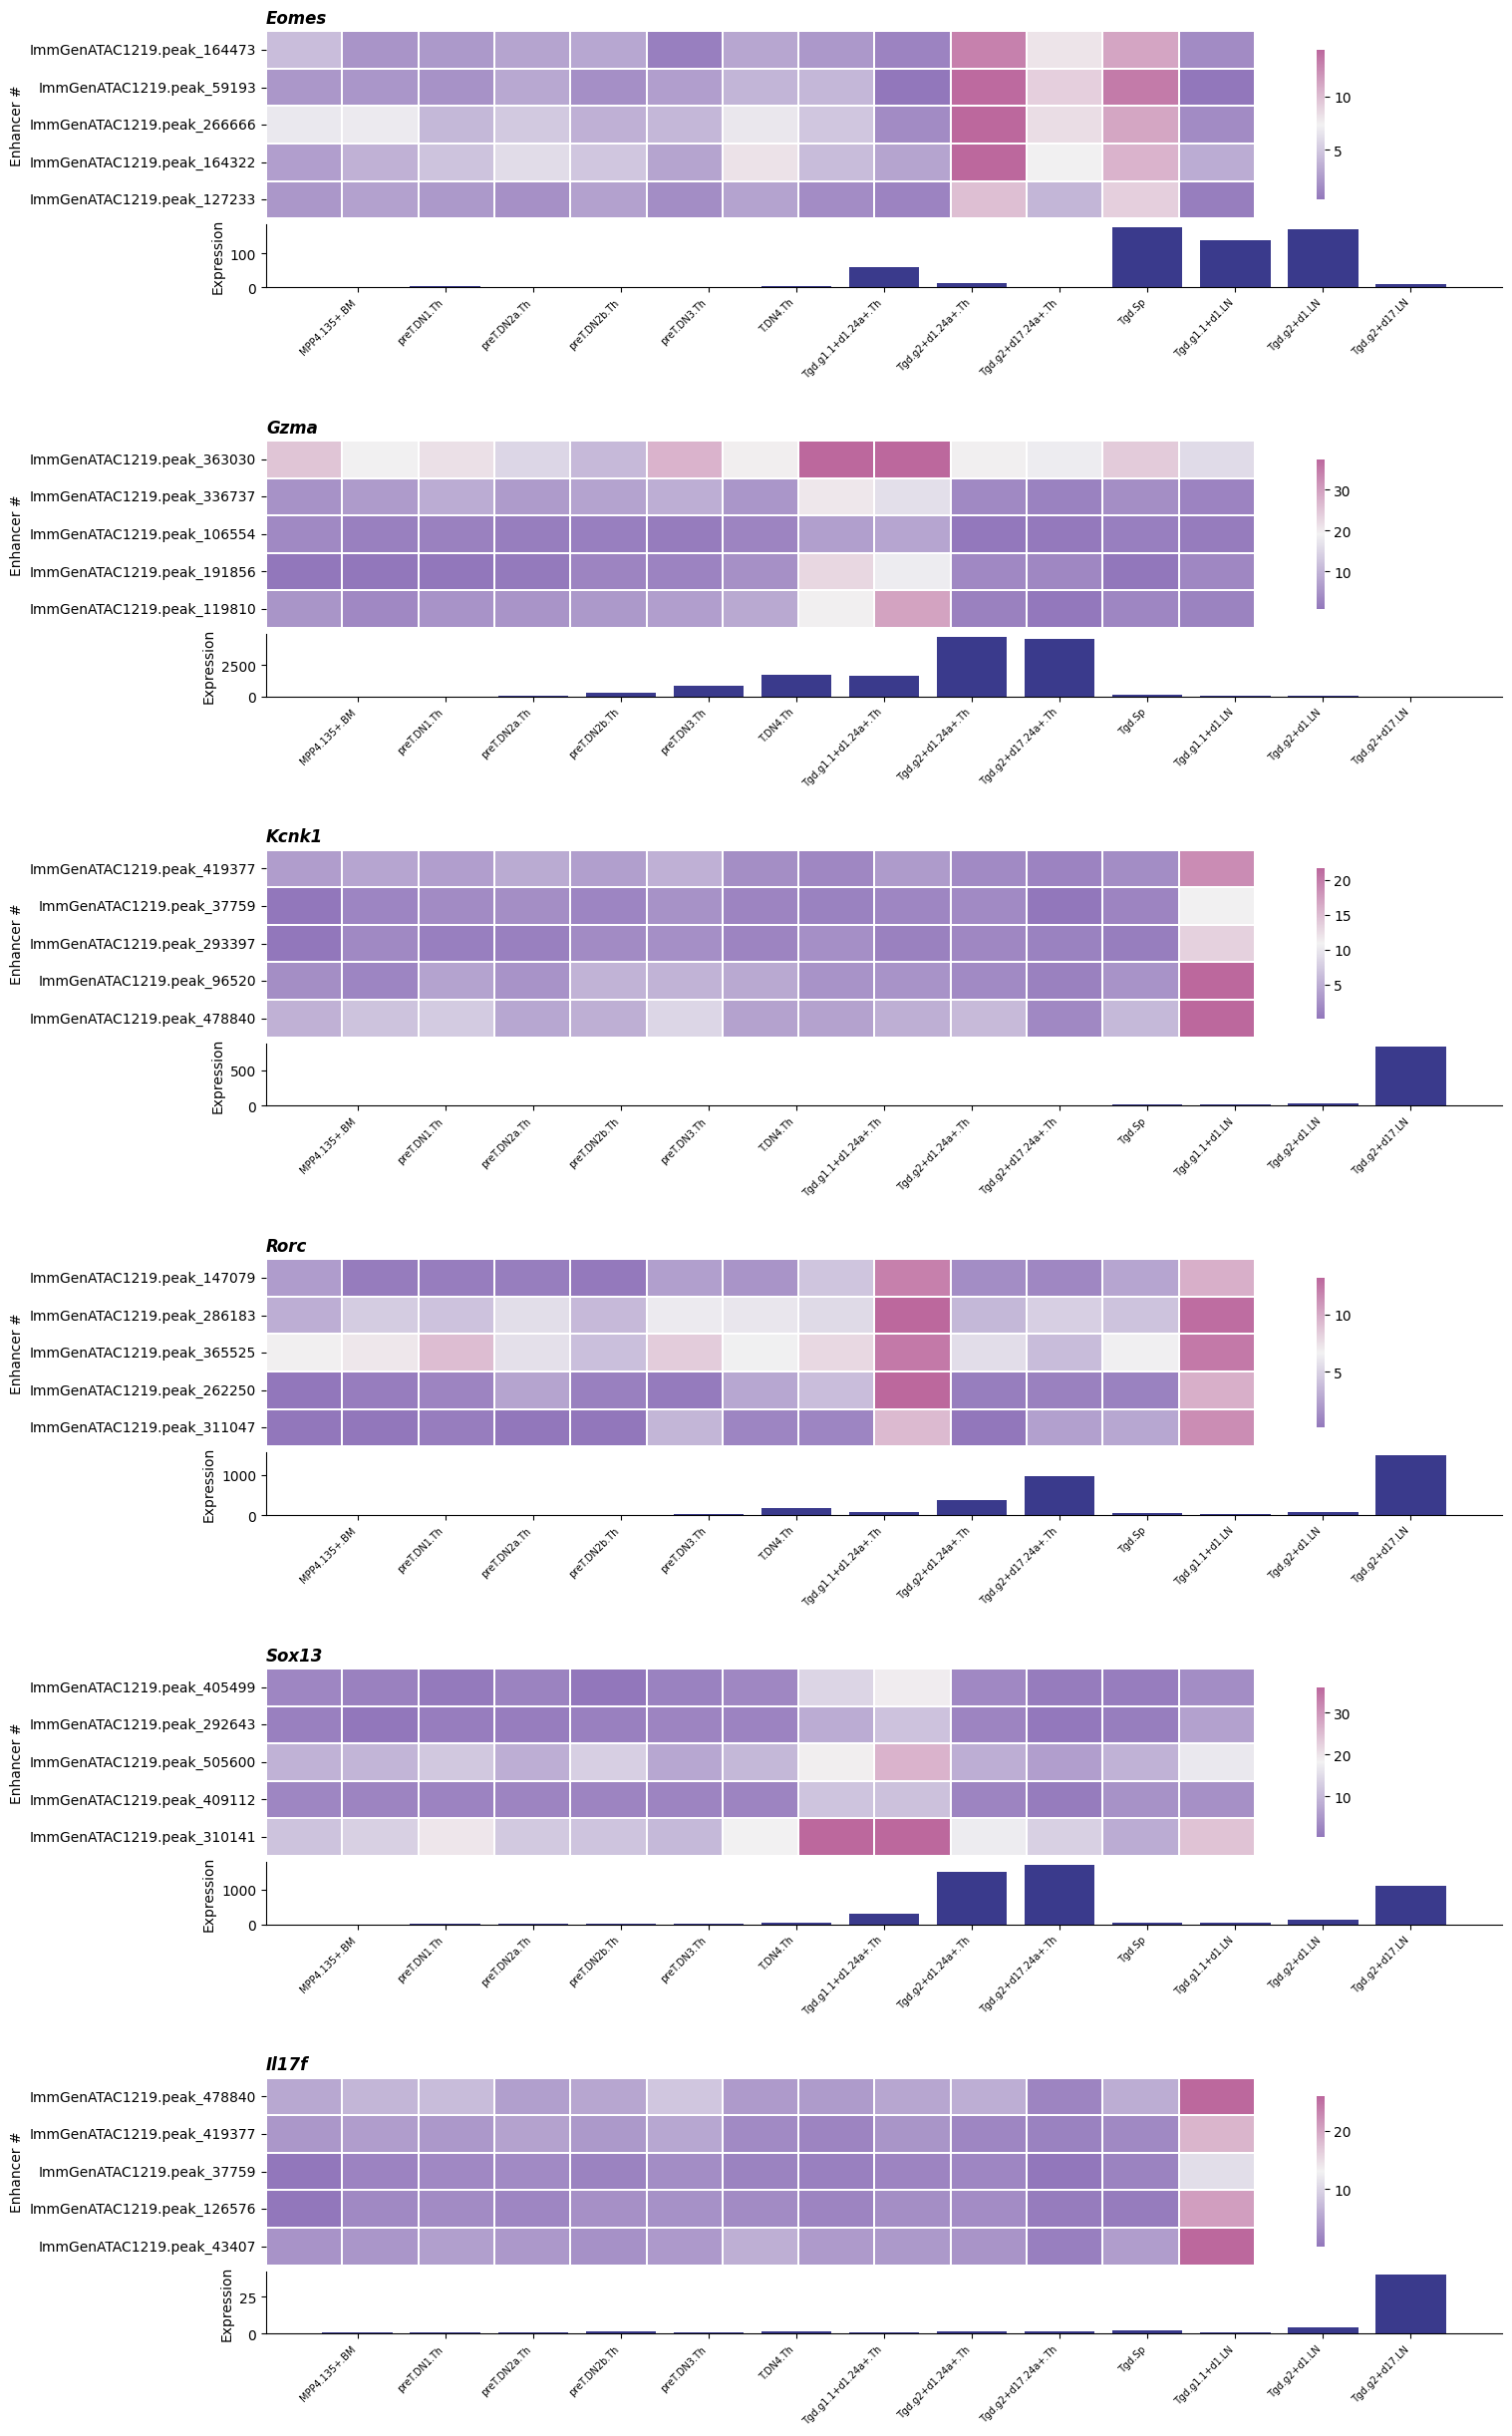

In [56]:
Tgd_cells = ["MPP4.135+.BM" ,
            "preT.DN1.Th" ,
            "preT.DN2a.Th" ,
            "preT.DN2b.Th" ,
            "preT.DN3.Th" ,
            "T.DN4.Th" ,
            "Tgd.g1.1+d1.24a+.Th" ,
            "Tgd.g2+d1.24a+.Th" ,
            "Tgd.g2+d17.24a+.Th" ,
            "Tgd.Sp" ,
            "Tgd.g1.1+d1.LN" ,
            "Tgd.g2+d1.LN" ,
            "Tgd.g2+d17.LN"
            ]

cmap = sns.diverging_palette(
    280,   # kühles Lila
    330,   # wärmeres Lila
    s=45,  # WENIGER Sättigung -> weniger grell
    l=55,  # mittlere Helligkeit -> guter Kontrast
    center="light",
    as_cmap=True
)

fig = plt.figure(figsize=(16, 5 * len(high_gini_Tgd)))
gs = fig.add_gridspec(len(high_gini_Tgd), 1, hspace=0.6)

for i, gen in enumerate(["Eomes", "Gzma", "Kcnk1", "Rorc", "Sox13", "Il17f"]):
    # Inneres gridspec: Heatmap oben (3 Teile), Barplot unten (1 Teil)
    inner = gs[i].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ax_heat = fig.add_subplot(inner[0])
    ax_bar  = fig.add_subplot(inner[1])

    # --- Heatmap ---
    #top 5 peaks von jedem gen nach Regressionsmodell: positiv Tgd peak und größten unterschied zu all cells
    top5 = coef_tables[gen][
        (coef_tables[gen]["Tgd"] > 0) & 
        (coef_tables[gen]["Tgd"] > coef_tables[gen]["all_cells"])
    ].sort_values("Tgd", ascending=False).head(5)

    #jede zeile ist ein peak dieser top5 und davon die ATAC zugäglichkeit
    rows = []
    for j, peak_id in enumerate(top5.index):
        row = ATAC_seq_gd[ATAC_seq_gd["ImmGenATAC1219.peakID"] == peak_id]
        if not row.empty:
            vals = row[Tgd_cells].iloc[0]
            vals.name = peak_id
            rows.append(vals)

    heat_df = pd.DataFrame(rows)
    heat_df_z = StandardScaler().fit_transform(heat_df.T)   # skaliert über Tgd-Zelltypen je Peak (dafür transformieren) --> damit alle peaks auf derselben skala liegen (z=2: Standartabweichung 2 besonders offen für den peak)
    heat_df_z = pd.DataFrame(heat_df_z.T, index=heat_df.index, columns=heat_df.columns)

    sns.heatmap(heat_df, ax=ax_heat, cmap=cmap, robust=True,
                linewidths=0.3, xticklabels=False, yticklabels=True,
                cbar_kws={"shrink": 0.8})
    ax_heat.set_title(gen, fontstyle="italic", fontweight="bold", loc="left")
    ax_heat.set_ylabel("Enhancer #")

    # Barplot RNA: RNA‑Expression des Gens in den Tγδ‑Zelltypen
    rna_row = RNA_seq_gd[RNA_seq_gd["Unnamed: 0"] == gen]
    if not rna_row.empty:
        rna_vals = rna_row[Tgd_cells].iloc[0]
        ax_bar.bar(range(len(Tgd_cells)), rna_vals.values, color="#3a3a8c")
        ax_bar.set_xticks(range(len(Tgd_cells)))
        ax_bar.set_xticklabels(Tgd_cells, rotation=45, ha='right', fontsize=7)
        ax_bar.set_ylabel("Expression")
        ax_bar.spines[['top','right']].set_visible(False)

plt.show()

für jedes Gen die Top‑5 Peaks nach Tγδ‑Koeffizienten bestimmt (die stärksten positiven Regressionskoeffizienten aufweisen und deren Einfluss dort größer ist als im all cells Modell)

* oben: ATAC‑Zugänglichkeit dieser Peaks über alle Zelltypen (Heatmap),

* unten: RNA‑Expression des Gens in denselben Zelltypen (Balken).

<br> Beobachtung

* In welchen Tγδ‑Subtypen sind diese „modell‑wichtigen“ CREs am stärksten offen
* Ob das Gen dort am stärksten exprimiert ist

Es wird sichtbar, in welchen Tγδ stadien hohe enhancer Aktivität und hohe Genexpression zusammenfallen, also wo die durch das Regressionsmodell identifizierten CREs die lineage spezifische Expression am stärksten zu treiben scheinen.

WICHTIG ZU SCHAUEN ON DAS ENHANCERS SIND UND DANNA RGUMENTIEREN FOLGEN ENAHNCER UND NICHT PROMOTOR DRIVEN LOGIC